# Code Review PR Diffs — Exploratory Analysis

Analyzing a sample of 100 GitHub PR diffs to understand structure, size, and content patterns.

In [36]:
import os
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DIFF_DIR = Path('../datasets/code-review/sample_100/diffs/')
SAMPLE_META = Path('../datasets/code-review/sample_100/metadata.csv')
MODELING_FILE = Path('../datasets/code-review/code_review_modeling_dataset.csv.gz')

# Load descriptions from the sample metadata
sample_meta = pd.read_csv(SAMPLE_META)

## 1. Parse diffs into structured data

In [37]:
def parse_diff(filepath):
    """Parse a unified diff file into structured info."""
    text = filepath.read_text(errors='replace')
    
    # Extract PR info from filename: owner__repo__number.diff
    parts = filepath.stem.split('__')
    owner, repo, pr_number = parts[0], parts[1], int(parts[2]) if len(parts) > 2 else 0
    
    # Count files changed
    file_headers = re.findall(r'^diff --git a/(.*?) b/', text, re.MULTILINE)
    
    # Count additions and deletions
    additions = len(re.findall(r'^\+[^+]', text, re.MULTILINE))
    deletions = len(re.findall(r'^-[^-]', text, re.MULTILINE))
    
    # File extensions
    extensions = [os.path.splitext(f)[1].lower() for f in file_headers]
    
    # Detect file types
    test_files = sum(1 for f in file_headers if 'test' in f.lower() or 'spec' in f.lower())
    doc_files = sum(1 for f in file_headers 
                    if any(f.lower().endswith(ext) for ext in ['.md', '.rst', '.txt', '.adoc']))
    config_files = sum(1 for f in file_headers 
                       if any(x in f.lower() for x in ['config', '.yml', '.yaml', '.json', '.toml', 'makefile', 'dockerfile']))
    
    return {
        'owner': owner,
        'repo': repo,
        'pr_number': pr_number,
        'total_chars': len(text),
        'total_lines': text.count('\n'),
        'num_files': len(file_headers),
        'additions': additions,
        'deletions': deletions,
        'net_change': additions - deletions,
        'extensions': extensions,
        'test_files': test_files,
        'doc_files': doc_files,
        'config_files': config_files,
        'code_files': len(file_headers) - test_files - doc_files - config_files,
        'text': text,
    }

diffs = [parse_diff(f) for f in sorted(DIFF_DIR.glob('*.diff'))]
df = pd.DataFrame(diffs)
print(f'Parsed {len(df)} diffs')
df[['owner', 'repo', 'pr_number', 'total_lines', 'num_files', 'additions', 'deletions']].describe().round(0)

Parsed 100 diffs


,pr_number,total_lines,num_files,additions,deletions
count,100.0,100.0,100.0,100.0,100.0
mean,1698.0,2095.0,26.0,1153.0,301.0
std,2118.0,2266.0,34.0,1317.0,582.0
min,15.0,79.0,1.0,8.0,0.0
25%,274.0,664.0,6.0,321.0,15.0
50%,906.0,1176.0,14.0,729.0,86.0
75%,2354.0,2629.0,31.0,1474.0,322.0
max,11002.0,11707.0,230.0,9108.0,4260.0


## 2. Join with accept/reject labels

In [38]:
# Load modeling dataset to get outcomes
labels = pd.read_csv(MODELING_FILE, usecols=['owner', 'repo', 'pr_number', 'outcome'])
labels = labels.groupby(['owner', 'repo', 'pr_number'])['outcome'].first().reset_index()

df = df.merge(labels, on=['owner', 'repo', 'pr_number'], how='left')
print(f"Matched outcomes: {df['outcome'].notna().sum()} / {len(df)}")
print()
print(df['outcome'].value_counts())

Matched outcomes: 99 / 100

outcome
accepted    85
rejected    14
Name: count, dtype: int64


In [39]:
# print(df['text'].iloc[0])

## 3. Diff size distribution

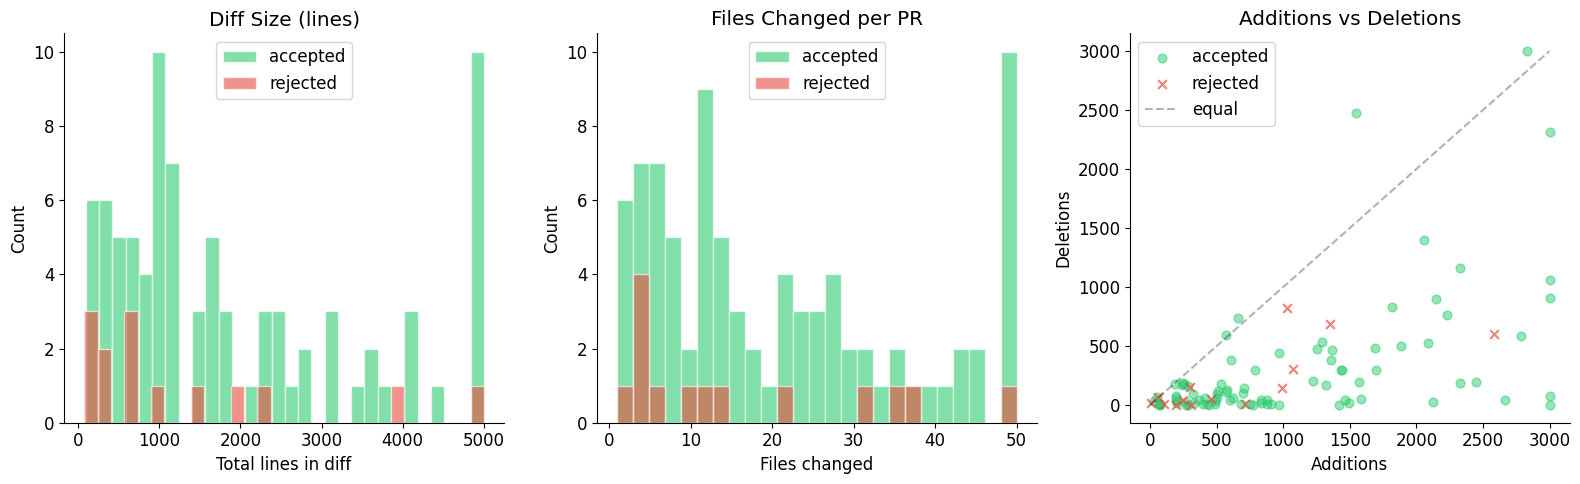

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total lines
ax = axes[0]
for outcome, color in [('accepted', '#2ecc71'), ('rejected', '#e74c3c')]:
    subset = df[df['outcome'] == outcome]
    ax.hist(subset['total_lines'].clip(upper=5000), bins=30, alpha=0.6, 
            label=outcome, color=color, edgecolor='white')
ax.set_xlabel('Total lines in diff')
ax.set_ylabel('Count')
ax.set_title('Diff Size (lines)')
ax.legend()

# Files changed
ax = axes[1]
for outcome, color in [('accepted', '#2ecc71'), ('rejected', '#e74c3c')]:
    subset = df[df['outcome'] == outcome]
    ax.hist(subset['num_files'].clip(upper=50), bins=25, alpha=0.6,
            label=outcome, color=color, edgecolor='white')
ax.set_xlabel('Files changed')
ax.set_ylabel('Count')
ax.set_title('Files Changed per PR')
ax.legend()

# Additions vs deletions
ax = axes[2]
accepted = df[df['outcome'] == 'accepted']
rejected = df[df['outcome'] == 'rejected']
ax.scatter(accepted['additions'].clip(upper=3000), accepted['deletions'].clip(upper=3000),
           alpha=0.5, c='#2ecc71', label='accepted', s=40)
ax.scatter(rejected['additions'].clip(upper=3000), rejected['deletions'].clip(upper=3000),
           alpha=0.7, c='#e74c3c', label='rejected', s=40, marker='x')
ax.plot([0, 3000], [0, 3000], 'k--', alpha=0.3, label='equal')
ax.set_xlabel('Additions')
ax.set_ylabel('Deletions')
ax.set_title('Additions vs Deletions')
ax.legend()

plt.tight_layout()
plt.show()

## 4. File type breakdown

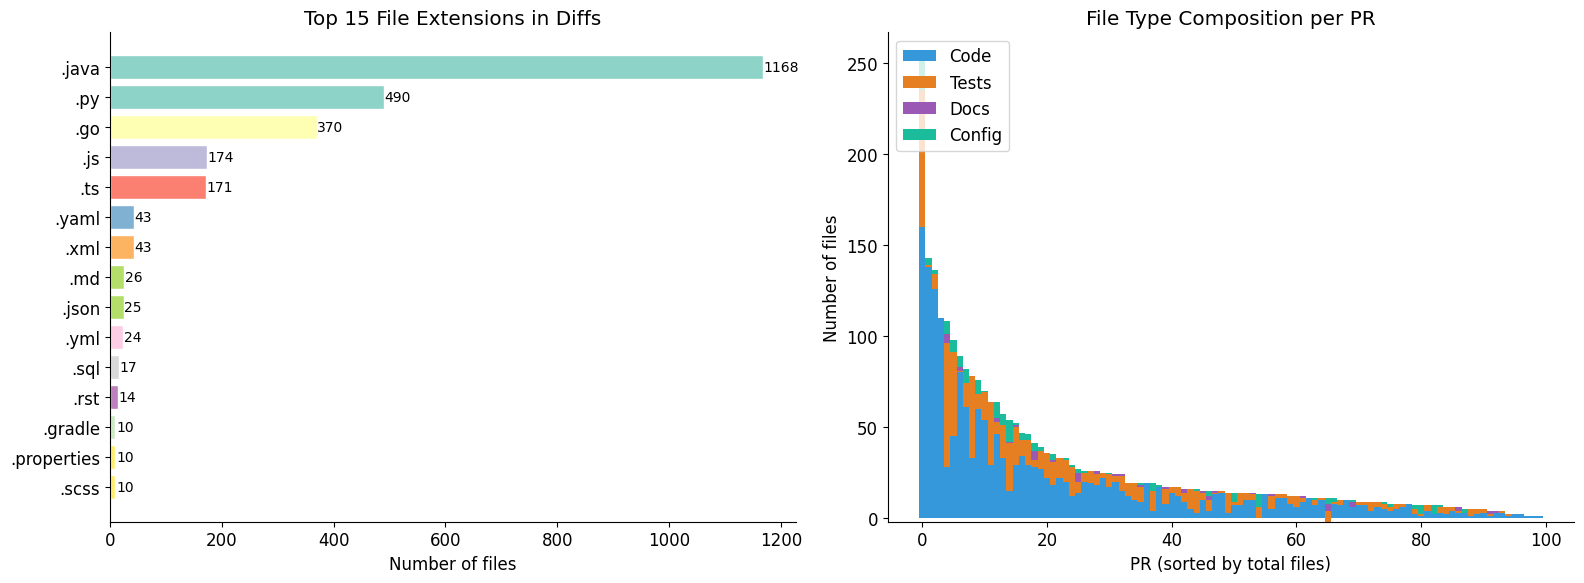

In [29]:
# Extension frequency
all_exts = [ext for exts in df['extensions'] for ext in exts if ext]
ext_counts = Counter(all_exts).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top extensions
ax = axes[0]
exts, counts = zip(*ext_counts)
colors = plt.cm.Set3(np.linspace(0, 1, len(exts)))
bars = ax.barh(range(len(exts)), counts, color=colors, edgecolor='white')
ax.set_yticks(range(len(exts)))
ax.set_yticklabels(exts)
ax.set_xlabel('Number of files')
ax.set_title('Top 15 File Extensions in Diffs')
ax.invert_yaxis()
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)

# File type composition per PR
ax = axes[1]
categories = ['code_files', 'test_files', 'doc_files', 'config_files']
cat_colors = ['#3498db', '#e67e22', '#9b59b6', '#1abc9c']
cat_labels = ['Code', 'Tests', 'Docs', 'Config']

bottoms = np.zeros(len(df))
sorted_df = df.sort_values('num_files', ascending=False).reset_index(drop=True)
for cat, color, label in zip(categories, cat_colors, cat_labels):
    vals = sorted_df[cat].values
    ax.bar(range(len(sorted_df)), vals, bottom=bottoms, color=color, label=label, width=1.0)
    bottoms += vals
ax.set_xlabel('PR (sorted by total files)')
ax.set_ylabel('Number of files')
ax.set_title('File Type Composition per PR')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 5. Content analysis — what's in the diffs?

In [42]:
def extract_diff_features(text):
    """Extract content-level features from a diff."""
    added_lines = re.findall(r'^\+(.+)$', text, re.MULTILINE)
    removed_lines = re.findall(r'^-(.+)$', text, re.MULTILINE)
    
    added_text = ' '.join(added_lines)
    removed_text = ' '.join(removed_lines)
    
    # Comment patterns
    comment_patterns = [r'//', r'#', r'/\*', r'\*/', r'"""', r"'''"]
    added_comments = sum(len(re.findall(p, added_text)) for p in comment_patterns)
    
    # Import/dependency changes
    import_adds = len(re.findall(r'\bimport\b|\brequire\b|\bfrom\b.*\bimport\b', added_text))
    import_removes = len(re.findall(r'\bimport\b|\brequire\b|\bfrom\b.*\bimport\b', removed_text))
    
    # Error handling
    error_handling = len(re.findall(
        r'\btry\b|\bcatch\b|\bexcept\b|\braise\b|\bthrow\b|\berror\b|\bError\b',
        added_text
    ))
    
    # Function/method definitions
    func_adds = len(re.findall(
        r'\bdef\b|\bfunc\b|\bfunction\b|\bfn\b|\bpub fn\b|void |int |String ',
        added_text
    ))
    
    # TODO/FIXME/HACK
    todos = len(re.findall(r'TODO|FIXME|HACK|XXX|NOQA', text, re.IGNORECASE))
    
    return {
        'added_comments': added_comments,
        'import_adds': import_adds,
        'import_removes': import_removes,
        'error_handling': error_handling,
        'func_additions': func_adds,
        'todos': todos,
        'avg_added_line_len': np.mean([len(l) for l in added_lines]) if added_lines else 0,
        'avg_removed_line_len': np.mean([len(l) for l in removed_lines]) if removed_lines else 0,
    }

features = pd.DataFrame([extract_diff_features(row['text']) for _, row in df.iterrows()])
df = pd.concat([df.drop(columns=['text', 'extensions']), features], axis=1)
df.head()

,owner,repo,pr_number,total_chars,total_lines,num_files,additions,deletions,net_change,test_files,...,code_files,outcome,added_comments,import_adds,import_removes,error_handling,func_additions,todos,avg_added_line_len,avg_removed_line_len
0,0chain,0chain,1509,65165,1849,28,704,142,562,3,...,23,accepted,21,18,8,55,16,1,31.568421,48.588235
1,Azure,WALinuxAgent,2145,97792,1722,14,574,595,-21,6,...,6,accepted,69,1,1,12,28,0,65.053704,65.220401
2,Blazebit,blaze-persistence,431,185397,3711,42,2447,197,2250,15,...,18,accepted,224,9,4,14,164,7,52.133721,66.978166
3,Chocobozzz,PeerTube,3933,183644,4867,46,2324,1163,1161,9,...,34,accepted,96,2,2,36,126,0,41.553375,42.493415
4,ExpediaGroup,stream-registry,273,185652,4025,83,1698,293,1405,22,...,60,accepted,55,213,13,34,49,0,46.891622,61.044077


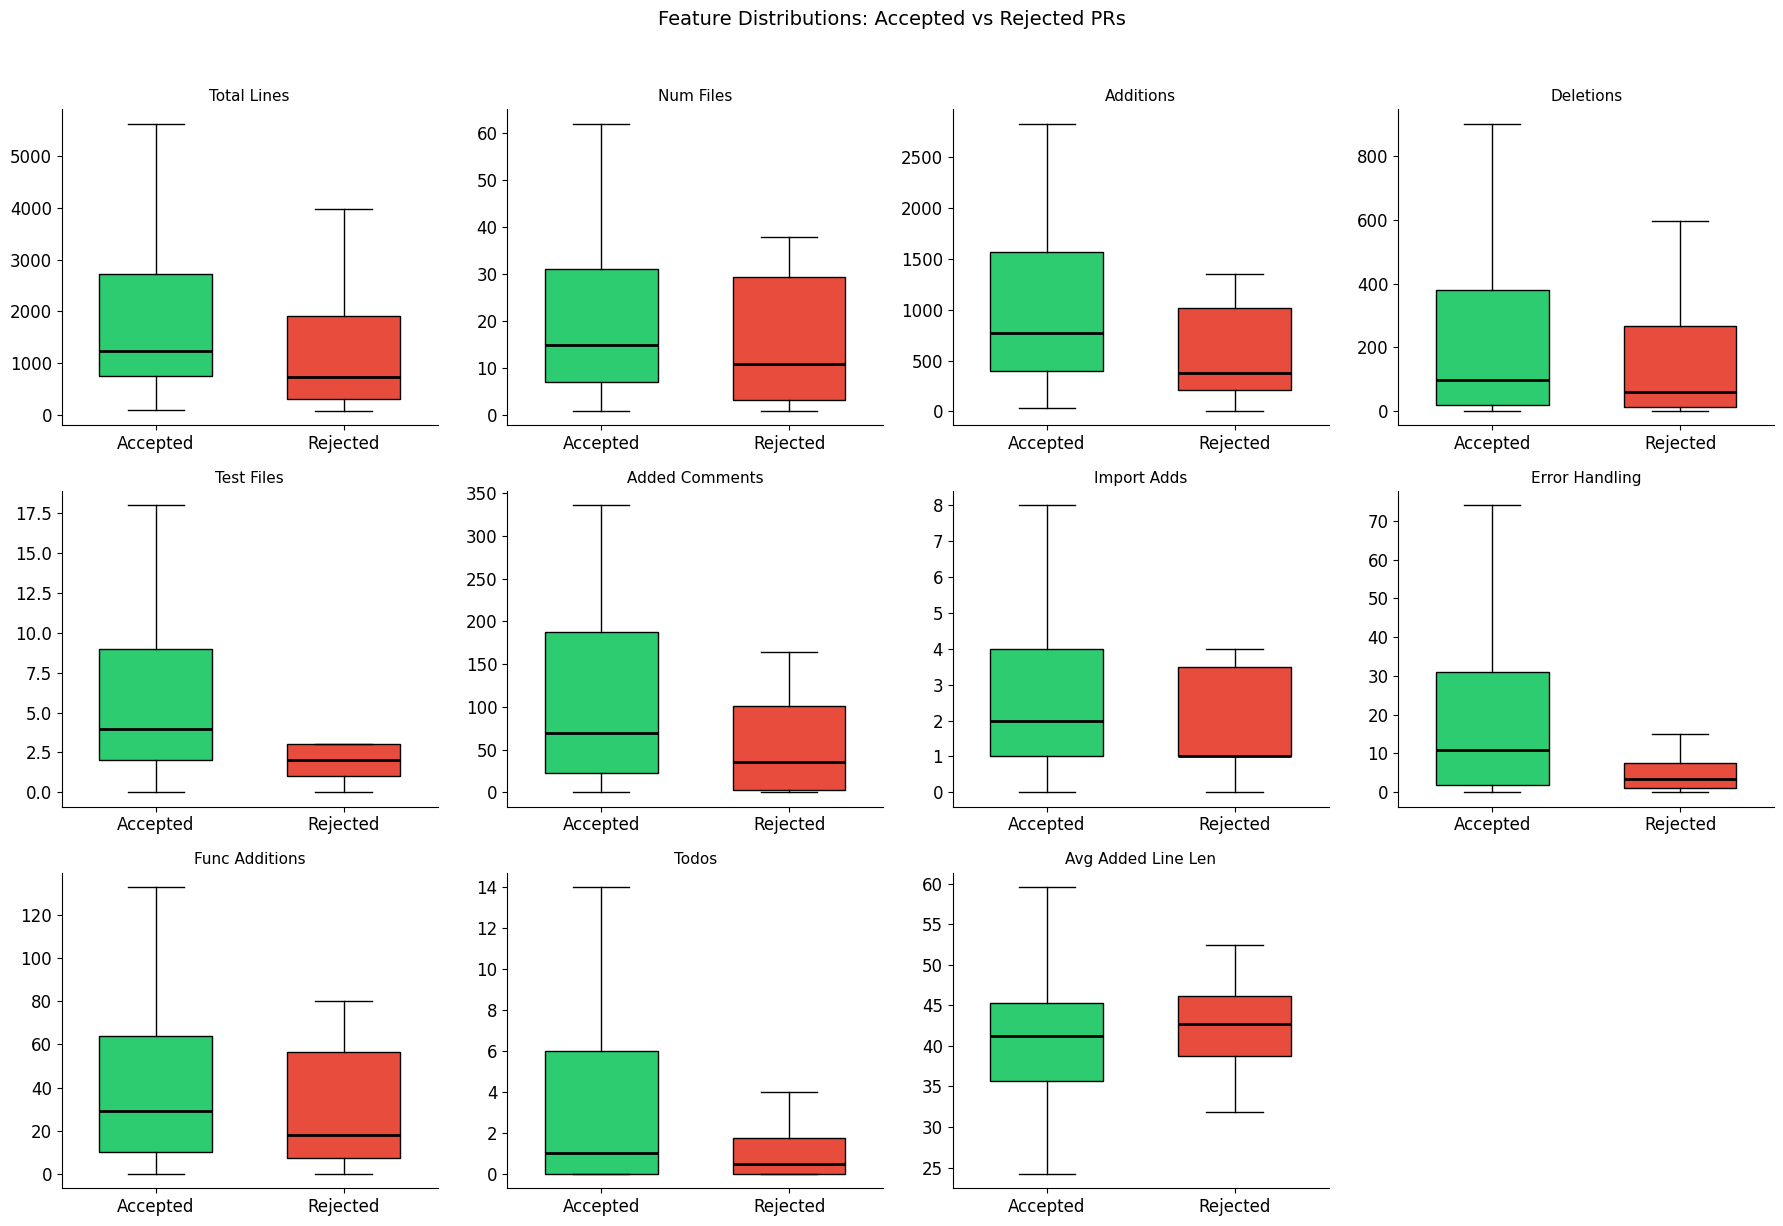

In [43]:
# Compare features between accepted and rejected
feature_cols = ['total_lines', 'num_files', 'additions', 'deletions',
                'test_files', 'added_comments', 'import_adds', 
                'error_handling', 'func_additions', 'todos',
                'avg_added_line_len']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    acc = df[df['outcome'] == 'accepted'][col].dropna()
    rej = df[df['outcome'] == 'rejected'][col].dropna()
    
    positions = [1, 2]
    bp = ax.boxplot([acc, rej], positions=positions, widths=0.6, patch_artist=True,
                    showfliers=False, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_xticks(positions)
    ax.set_xticklabels(['Accepted', 'Rejected'])
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)

# Hide extra subplot
axes[-1].set_visible(False)

fig.suptitle('Feature Distributions: Accepted vs Rejected PRs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Diff complexity — token estimates for modeling

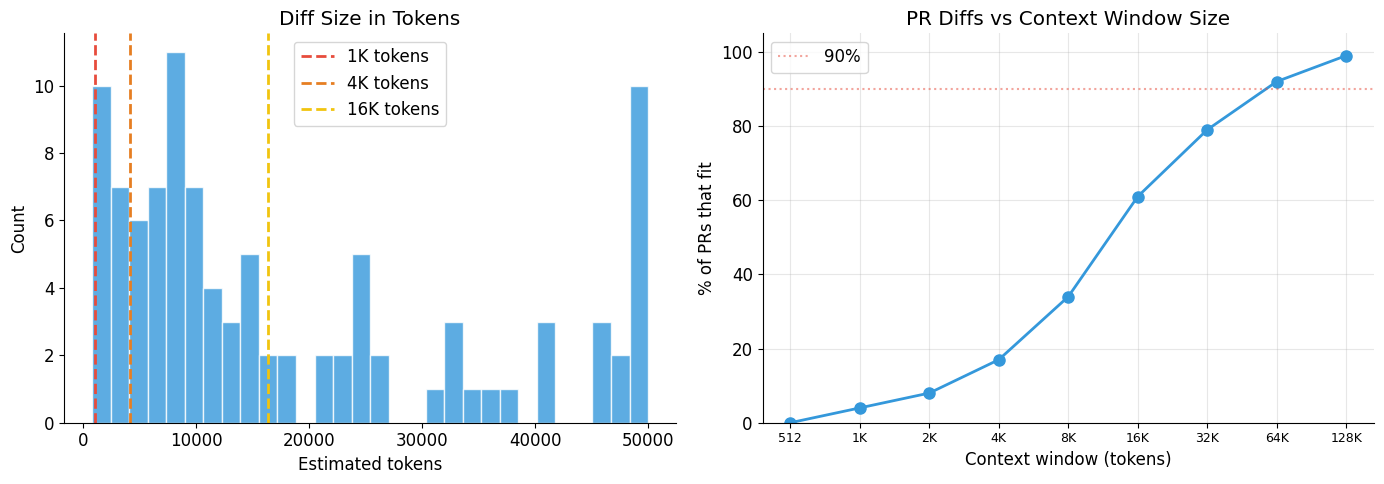

Token percentiles:
  25th: 5,902 tokens
  50th: 11,123 tokens
  75th: 27,678 tokens
  90th: 48,276 tokens
  95th: 77,980 tokens
  99th: 111,406 tokens


In [44]:
# Estimate tokens (rough: chars / 4)
df['est_tokens'] = df['total_chars'] / 4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Token distribution
ax = axes[0]
ax.hist(df['est_tokens'].clip(upper=50000), bins=30, color='#3498db', 
        edgecolor='white', alpha=0.8)
for limit, label, color in [(1024, '1K tokens', '#e74c3c'), 
                             (4096, '4K tokens', '#e67e22'),
                             (16384, '16K tokens', '#f1c40f')]:
    ax.axvline(limit, color=color, linestyle='--', linewidth=2, label=label)
ax.set_xlabel('Estimated tokens')
ax.set_ylabel('Count')
ax.set_title('Diff Size in Tokens')
ax.legend()

# What fraction fits in various context windows?
ax = axes[1]
windows = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
fractions = [100 * (df['est_tokens'] <= w).mean() for w in windows]
ax.plot(windows, fractions, 'o-', color='#3498db', linewidth=2, markersize=8)
ax.set_xscale('log', base=2)
ax.set_xlabel('Context window (tokens)')
ax.set_ylabel('% of PRs that fit')
ax.set_title('PR Diffs vs Context Window Size')
ax.set_ylim(0, 105)
ax.axhline(90, color='#e74c3c', linestyle=':', alpha=0.5, label='90%')
ax.legend()
ax.grid(True, alpha=0.3)
# Format x-axis ticks nicely
ax.set_xticks(windows)
ax.set_xticklabels(['512', '1K', '2K', '4K', '8K', '16K', '32K', '64K', '128K'],
                    fontsize=9)

plt.tight_layout()
plt.show()

print('Token percentiles:')
for p in [25, 50, 75, 90, 95, 99]:
    val = df['est_tokens'].quantile(p/100)
    print(f'  {p}th: {val:,.0f} tokens')

## 7. Sample PRs — description + colored diff (accepted vs rejected)

In [45]:
from IPython.display import display, HTML
import textwrap

def render_colored_diff(text, max_lines=80):
    """Render a unified diff with colored lines as HTML."""
    lines = text.split('\n')[:max_lines]
    html_parts = ['<pre style="font-family: monospace; font-size: 12px; line-height: 1.4; '
                  'background: #1e1e1e; color: #d4d4d4; padding: 12px; border-radius: 6px; '
                  'overflow-x: auto;">']
    
    for line in lines:
        escaped = line.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
        if line.startswith('+++') or line.startswith('---'):
            html_parts.append(f'<span style="color: #569cd6; font-weight: bold;">{escaped}</span>')
        elif line.startswith('@@'):
            html_parts.append(f'<span style="color: #c586c0;">{escaped}</span>')
        elif line.startswith('diff --git'):
            html_parts.append(f'<span style="color: #dcdcaa; font-weight: bold;">{escaped}</span>')
        elif line.startswith('+'):
            html_parts.append(f'<span style="background: #1e3a1e; color: #6a9955; display: block;">{escaped}</span>')
        elif line.startswith('-'):
            html_parts.append(f'<span style="background: #3a1e1e; color: #f48771; display: block;">{escaped}</span>')
        else:
            html_parts.append(f'<span>{escaped}</span>')
        
        if not line.startswith('+') and not line.startswith('-'):
            html_parts.append('\n')
    
    html_parts.append('</pre>')
    return ''.join(html_parts)


def render_description(body_text):
    """Render PR description as styled HTML."""
    if not body_text or pd.isna(body_text) or len(str(body_text).strip()) == 0:
        return '<p style="color: #888; font-style: italic;">No description provided.</p>'
    
    escaped = str(body_text)[:2000].replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
    # Preserve newlines
    escaped = escaped.replace('\n', '<br>')
    
    html = (
        '<div style="background: #f8f9fa; border-left: 4px solid #3498db; '
        'padding: 12px 16px; margin: 8px 0; border-radius: 0 6px 6px 0; '
        'font-family: -apple-system, sans-serif; font-size: 13px; '
        'line-height: 1.6; color: #333; max-height: 300px; overflow-y: auto;">'
        f'{escaped}'
    )
    if len(str(body_text)) > 2000:
        html += '<br><span style="color: #888;">... (truncated)</span>'
    html += '</div>'
    return html


# Merge descriptions into df
desc_cols = sample_meta[['owner', 'repo', 'pr_number', 'pr_body', 'pr_title']].copy()
desc_cols['pr_number'] = desc_cols['pr_number'].astype(int)
df_with_desc = df.merge(desc_cols, on=['owner', 'repo', 'pr_number'], how='left')

# Show 3 accepted and 3 rejected, picking small-to-medium sized PRs
for outcome in ['accepted', 'rejected']:
    subset = df_with_desc[df_with_desc['outcome'] == outcome]
    # Pick 3 with varying sizes
    samples = subset.nsmallest(3, 'total_lines')
    
    for _, row in samples.iterrows():
        diff_key = f"{row['owner']}__{row['repo']}__{int(row['pr_number'])}"
        diff_path = DIFF_DIR / f"{diff_key}.diff"
        if not diff_path.exists():
            continue
        text = diff_path.read_text(errors='replace')
        
        badge_color = '#2ecc71' if outcome == 'accepted' else '#e74c3c'
        title = row.get('pr_title', row.get('pr_title_x', ''))
        
        # Header with badge
        display(HTML(
            f'<div style="margin: 20px 0 5px 0; padding-top: 15px; border-top: 2px solid #ddd;">'
            f'<span style="background: {badge_color}; color: white; padding: 4px 10px; '
            f'border-radius: 4px; font-weight: bold; font-size: 14px;">{outcome.upper()}</span>'
            f'&nbsp; <b style="font-size: 14px;">{row["owner"]}/{row["repo"]}#{int(row["pr_number"])}</b>'
            f'&nbsp; | Files: {row["num_files"]} | '
            f'<span style="color: #2ecc71;">+{row["additions"]}</span> '
            f'<span style="color: #e74c3c;">-{row["deletions"]}</span>'
            f'<br><span style="font-size: 15px; font-weight: bold; color: #222;">{title}</span>'
            f'</div>'
        ))
        
        # PR Description
        display(HTML('<b style="color: #555;">PR Description:</b>'))
        display(HTML(render_description(row.get('pr_body', ''))))
        
        # Colored diff
        display(HTML('<b style="color: #555;">Code Diff:</b>'))
        display(HTML(render_colored_diff(text, max_lines=60)))
        if text.count('\n') > 60:
            print(f'  ... ({text.count(chr(10)) - 60} more lines)')

  ... (37 more lines)


  ... (49 more lines)


  ... (88 more lines)


  ... (19 more lines)


  ... (112 more lines)


  ... (164 more lines)


## 8. Summary statistics

In [46]:
summary = df.groupby('outcome').agg({
    'total_lines': ['mean', 'median'],
    'num_files': ['mean', 'median'],
    'additions': ['mean', 'median'],
    'deletions': ['mean', 'median'],
    'test_files': 'mean',
    'error_handling': 'mean',
    'func_additions': 'mean',
    'est_tokens': ['mean', 'median'],
}).round(1)

print(summary.to_string())

         total_lines         num_files        additions        deletions        test_files error_handling func_additions est_tokens         
                mean  median      mean median      mean median      mean median       mean           mean           mean       mean   median
outcome                                                                                                                                     
accepted      2194.6  1239.0      26.0   15.0    1228.7  773.0     319.8   97.0        8.2           23.2           56.5    27806.2  12056.0
rejected      1519.1   727.0      25.5   11.0     672.8  382.0     207.8   59.5       12.4            7.1           37.7    14825.4   6756.8
